# OpenCV Functions Implementation

## Reading & Writing Images

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((300, 400, 3), dtype=np.uint8)
img[:, :] = [100, 150, 200]

cv2.imwrite('sample_image.jpg', img)
print("Image saved successfully")

loaded_img = cv2.imread('sample_image.jpg')
print(f"Image loaded with shape: {loaded_img.shape}")

Image saved successfully
Image loaded with shape: (300, 400, 3)


## Displaying Images

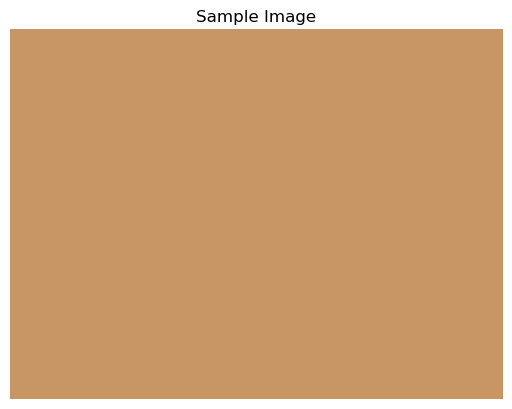

In [20]:
plt.imshow(cv2.cvtColor(loaded_img, cv2.COLOR_BGR2RGB))
plt.title('Sample Image')
plt.axis('off')
plt.show()

## Resizing & Cropping

Resized image shape: (150, 200, 3)
Cropped image shape: (150, 200, 3)


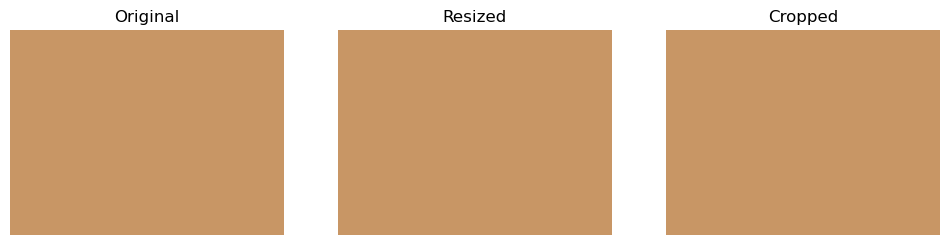

In [21]:
resized_img = cv2.resize(loaded_img, (200, 150))
print(f"Resized image shape: {resized_img.shape}")

cropped_img = loaded_img[50:200, 100:300]
print(f"Cropped image shape: {cropped_img.shape}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(loaded_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Resized')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
axes[2].set_title('Cropped')
axes[2].axis('off')
plt.show()

## Color Spaces

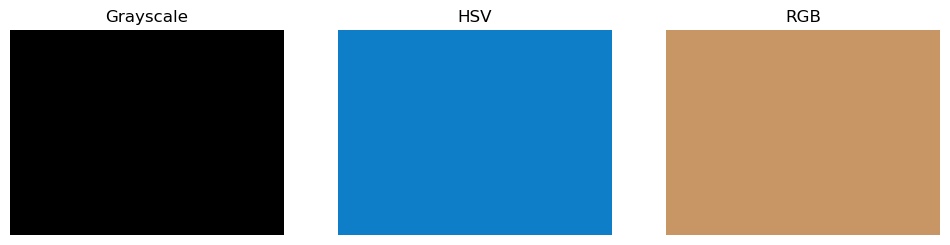

In [22]:
gray_img = cv2.cvtColor(loaded_img, cv2.COLOR_BGR2GRAY)
hsv_img = cv2.cvtColor(loaded_img, cv2.COLOR_BGR2HSV)
rgb_img = cv2.cvtColor(loaded_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Grayscale')
axes[0].axis('off')
axes[1].imshow(hsv_img)
axes[1].set_title('HSV')
axes[1].axis('off')
axes[2].imshow(rgb_img)
axes[2].set_title('RGB')
axes[2].axis('off')
plt.show()

## Drawing Shapes

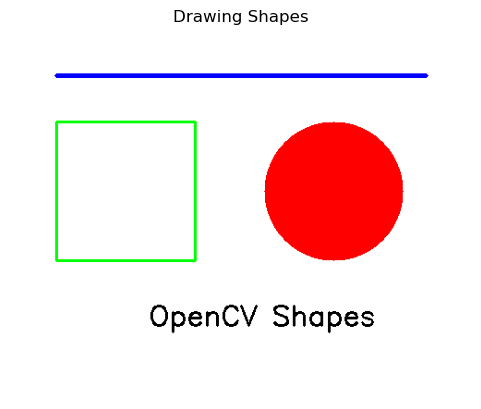

In [23]:
canvas = np.ones((400, 500, 3), dtype=np.uint8) * 255

cv2.line(canvas, (50, 50), (450, 50), (255, 0, 0), 3)
cv2.rectangle(canvas, (50, 100), (200, 250), (0, 255, 0), 2)
cv2.circle(canvas, (350, 175), 75, (0, 0, 255), -1)
cv2.putText(canvas, 'OpenCV Shapes', (150, 320), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title('Drawing Shapes')
plt.axis('off')
plt.show()

## Image Thresholding

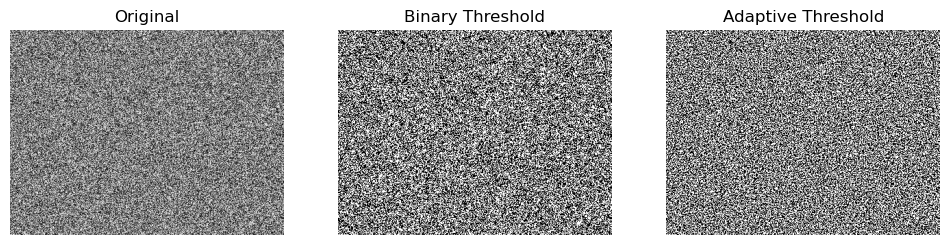

In [24]:
test_img = np.random.randint(0, 256, (300, 400), dtype=np.uint8)

ret, binary_thresh = cv2.threshold(test_img, 127, 255, cv2.THRESH_BINARY)
adaptive_thresh = cv2.adaptiveThreshold(test_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(binary_thresh, cmap='gray')
axes[1].set_title('Binary Threshold')
axes[1].axis('off')
axes[2].imshow(adaptive_thresh, cmap='gray')
axes[2].set_title('Adaptive Threshold')
axes[2].axis('off')
plt.show()

## Edge Detection

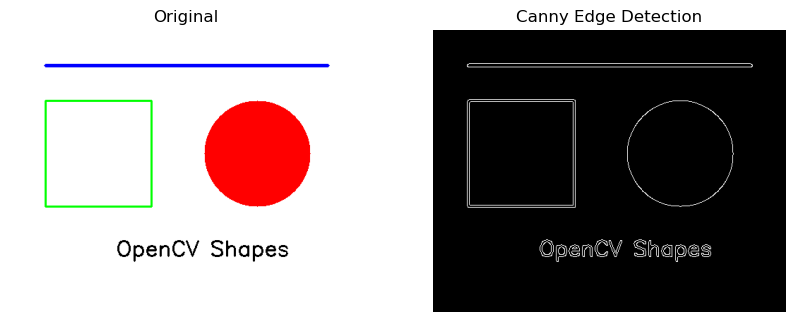

In [25]:
edge_img = cv2.Canny(canvas, 100, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(edge_img, cmap='gray')
axes[1].set_title('Canny Edge Detection')
axes[1].axis('off')
plt.show()

## Contours & Shape Detection

Number of contours found: 2


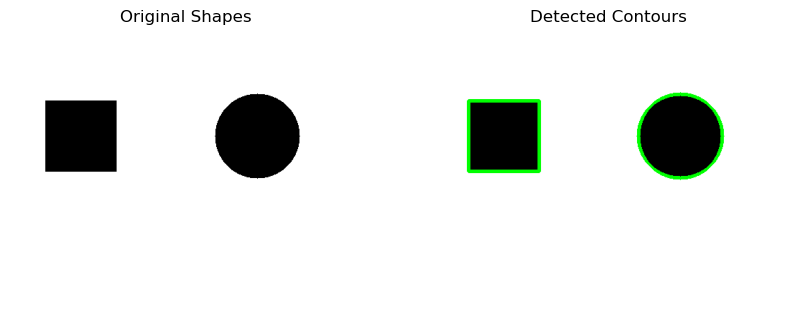

In [26]:
shape_canvas = np.ones((400, 500, 3), dtype=np.uint8) * 255
cv2.rectangle(shape_canvas, (50, 100), (150, 200), (0, 0, 0), -1)
cv2.circle(shape_canvas, (350, 150), 60, (0, 0, 0), -1)

gray = cv2.cvtColor(shape_canvas, cv2.COLOR_BGR2GRAY)
contours, hierarchy = cv2.findContours(cv2.bitwise_not(gray), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = shape_canvas.copy()
cv2.drawContours(result, contours, -1, (0, 255, 0), 3)

print(f"Number of contours found: {len(contours)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(shape_canvas, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Shapes')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1].set_title('Detected Contours')
axes[1].axis('off')
plt.show()

## Face Detection

Number of faces detected: 0


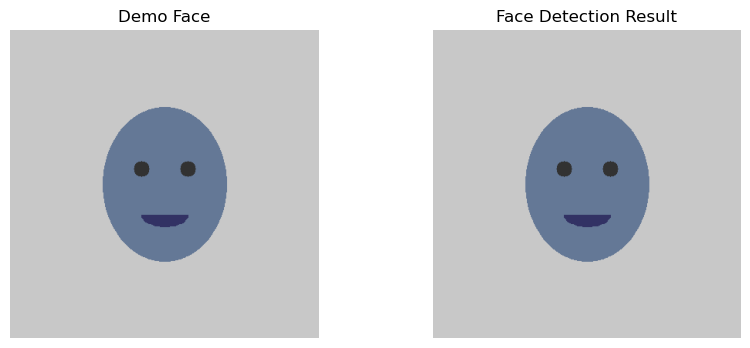

In [27]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

demo_face = np.ones((400, 400, 3), dtype=np.uint8) * 200
cv2.ellipse(demo_face, (200, 200), (80, 100), 0, 0, 360, (150, 120, 100), -1)
cv2.circle(demo_face, (170, 180), 10, (50, 50, 50), -1)
cv2.circle(demo_face, (230, 180), 10, (50, 50, 50), -1)
cv2.ellipse(demo_face, (200, 240), (30, 15), 0, 0, 180, (100, 50, 50), -1)

gray_face = cv2.cvtColor(demo_face, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray_face, 1.1, 4)

result_face = demo_face.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(result_face, (x, y), (x+w, y+h), (0, 255, 0), 2)

print(f"Number of faces detected: {len(faces)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(demo_face, cv2.COLOR_BGR2RGB))
axes[0].set_title('Demo Face')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(result_face, cv2.COLOR_BGR2RGB))
axes[1].set_title('Face Detection Result')
axes[1].axis('off')
plt.show()